# Capstone — Refresh / Content Opportunity Scoring

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Davionnic/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

**Author:** Dave Andrei Almia Gallo (`Davionnic`) · gallodave.cs@gmail.com  
**Lane:** Refresh / Content Opportunity Scoring  
**Repo:** https://github.com/Davionnic/flyrank-ml-internship  
**Paper:** https://davionnic.github.io/flyrank-ml-internship/paper/  
**Claim stance:** observed / measured / directional / **decision-support** (not causal)

This notebook mirrors the deployed research paper. Code cells **load committed receipts** under `work/outputs/*.json` (and optional charts) rather than inventing new training numbers. Simple words, honest metrics.

> Skills used: `skills/README.md` → `writing-research-papers` + `writing-honest-claims` (+ `flyrank-data` for data notes).

## 1. Question

**Research question:** Which existing pages should a content reviewer open first when organic demand looks soft?

**Decision supported:** ranked triage for human refresh review — not auto-publish, not a causal claim that refreshing causes recovery.

| Axis | Choice |
|---|---|
| Unit | Page (content item) |
| Output | Score + action + confidence + reason codes |
| Metric | Precision@K on a client-holdout split |
| Proxy label | `is_declining_label = (trend_direction == "down")` |

A wrong high rank wastes editor time; a miss leaves a high-demand soft page unreviewed. ML helps only if a validated ranker beats a transparent hand rule on a split that does not leak client identity.

In [1]:
import os
import json
from pathlib import Path

import pandas as pd

# Walk up until we find the repo root (works from work/notebooks/ or Colab)
while not os.path.isdir("data/raw") and os.getcwd() != "/":
    os.chdir("..")

ROOT = Path(".").resolve()
OUT = ROOT / "work" / "outputs"
PAPER_CHARTS = ROOT / "docs" / "paper" / "charts"
assert OUT.is_dir(), f"missing outputs dir: {OUT}"

print("ROOT =", ROOT)
print("outputs =", OUT)
print("paper charts exist =", PAPER_CHARTS.is_dir())

ROOT = /workspace/flyrank-ml-internship
outputs = /workspace/flyrank-ml-internship/work/outputs
paper charts exist = True


## 2. Data

**Release:** FlyRank ML Internship anonymized starter — `data/raw/content_refresh_anonymized.csv`.

| Item | Detail |
|---|---|
| Size | 30,000 pages × 44 public-safe columns |
| Clients | 32 pseudonymous `client_id` values |
| Window | Trailing-90-day metrics (teaching snapshot) |
| Label | `is_declining_label = (trend_direction == "down")` |
| Excluded from features | `trend_direction`, `trend_pct`, IDs as features, client-/URL-/query-identifying fields |

Public-safe: no private names, addresses, or raw queries in this notebook or the paper. Rate columns are ×100 percentages (`ctr = 0.76` means 0.76%). `avg_position = 0` means missing, not rank zero.

In [2]:
csv_path = ROOT / "data" / "raw" / "content_refresh_anonymized.csv"
df = pd.read_csv(csv_path)
df["is_declining_label"] = (df["trend_direction"].astype(str) == "down").astype(int)

print("rows × cols:", df.shape)
print("n_clients:", df["client_id"].nunique())
print("full-set decline base rate:", round(df["is_declining_label"].mean(), 6))

# Public-safety spot check: these columns must not be treated as free-text identifiers in features
forbidden_as_features = {"trend_direction", "trend_pct", "is_declining_label", "client_id", "content_id"}
print("forbidden_as_features =", sorted(forbidden_as_features))
print("sample columns (first 12):", list(df.columns[:12]))

rows × cols: (30000, 45)
n_clients: 32
full-set decline base rate: 0.542067
forbidden_as_features = ['client_id', 'content_id', 'is_declining_label', 'trend_direction', 'trend_pct']
sample columns (first 12): ['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used']


## 3. Methodology

**Assumptions.** Cross-sectional snapshot. Decline label is a *proxy* for refresh worthiness, not editor ground truth. Rankings support review; they do not auto-publish.

**Baseline (ML-07).** Weighted hand score: `0.4·visibility + 0.3·freshness_risk + 0.25·position_opportunity + 0.05·depth_gap`.

**Models (ML-08).** Logistic regression, decision tree, Random Forest on 52 engineered features (`random_state=42`). Same client-holdout as the baseline.

**Leakage controls (ML-09).** Empty forbidden overlap with label fields. Injecting `trend_pct` collapses Prec@50 to 1.0 (red-team). Random-row Prec@50 = 0.90 vs client-holdout 0.68 — publish the grouped split.

**Playbook (ML-10).** Queue score ≈ `0.7·model_probability + 0.3·baseline_normalized` + reason codes + human-review gates.

The next cell loads the committed JSON receipts instead of re-training.

In [3]:
def load_json(name: str) -> dict:
    path = OUT / name
    with path.open() as f:
        data = json.load(f)
    print(f"loaded {path.relative_to(ROOT)}")
    return data

baseline = load_json("baseline_action_score_metrics.json")
model = load_json("model_holdout_metrics.json")
audit = load_json("validation_audit_metrics.json")
playbook = load_json("action_playbook_metrics.json")

assert baseline["split"] == model["split"] == "client_holdout"
assert model["random_state"] == 42
assert model["best_model"] == "random_forest"
assert baseline["precision_at_50_holdout"] == model["baseline_precision_at_50_holdout"] == 0.24
assert model["best_model_precision_at_50_holdout"] == 0.68
assert model["train_rows"] == 27675 and model["test_rows"] == 2325

print("\n--- methodology receipts ---")
print("label:", model["label"])
print("split:", model["split"], "| random_state:", model["random_state"])
print("train/test:", model["train_rows"], "/", model["test_rows"])
print("feature_count:", model["feature_count"], "| sklearn:", model["sklearn_version"])
print("baseline formula weights:", baseline["score_formula"])
print("playbook blend:", playbook["score_blend"])
print("forbidden_overlap (audit):", audit["forbidden_overlap"])
print("leak trend_pct Prec@50:", audit["leak_trend_pct_precision_at_50"])

loaded work/outputs/baseline_action_score_metrics.json
loaded work/outputs/model_holdout_metrics.json
loaded work/outputs/validation_audit_metrics.json
loaded work/outputs/action_playbook_metrics.json

--- methodology receipts ---
label: is_declining_label = (trend_direction == 'down')
split: client_holdout | random_state: 42
train/test: 27675 / 2325
feature_count: 52 | sklearn: 1.9.1
baseline formula weights: {'visibility_score': 0.4, 'freshness_risk_score': 0.3, 'position_opportunity_score': 0.25, 'depth_gap_score': 0.05}
playbook blend: {'model_probability': 0.7, 'baseline_normalized': 0.3}
forbidden_overlap (audit): []
leak trend_pct Prec@50: 1.0


## 4. Results (vs baseline)

Same client-holdout for every row. Holdout base rate **0.391**. Headline: baseline Prec@50 **0.240** → Random Forest Prec@50 **0.680** (≈2.8×). Holdout top-50 proxy positives: **34 / 50**.

Numbers below are loaded from `work/outputs/model_holdout_metrics.json` and the audit/playbook receipts — not typed by hand in isolation.

In [4]:
rows = [
    {
        "method": "baseline_rules",
        "precision_at_20": baseline["precision_at_20_holdout"],
        "precision_at_50": baseline["precision_at_50_holdout"],
        "average_precision": None,
        "roc_auc": None,
    }
]
for name, m in model["models"].items():
    rows.append(
        {
            "method": name + (" ★" if name == model["best_model"] else ""),
            "precision_at_20": m["precision_at_20"],
            "precision_at_50": m["precision_at_50"],
            "average_precision": round(m["average_precision"], 3),
            "roc_auc": round(m["roc_auc"], 3),
        }
    )

results = pd.DataFrame(rows)
display(results)

br = model["base_rate_test"]
print(f"holdout base rate: {br:.5f}")
print(
    f"headline Prec@50: baseline {model['baseline_precision_at_50_holdout']} → "
    f"RF {model['best_model_precision_at_50_holdout']} "
    f"(lift ≈ {model['best_model_precision_at_50_holdout'] / model['baseline_precision_at_50_holdout']:.2f}×)"
)
print("holdout_top50_positives:", model["holdout_top50_positives"])

print("\n--- split audit ---")
print("random-row RF Prec@50:", audit["precision_at_50_before_random"])
print("client-holdout RF Prec@50:", audit["precision_at_50_after_client"])
print("gap (random − client):", round(audit["precision_at_50_gap_random_minus_client"], 3))

feat = pd.DataFrame(model["best_model_top_features"])
print("\n--- top RF importances (receipt) ---")
display(feat.head(10))

,method,precision_at_20,precision_at_50,average_precision,roc_auc
0,baseline_rules,0.15,0.24,NaN,NaN
1,logistic_regression,0.35,0.40,0.522,0.700
2,decision_tree,0.65,0.66,0.575,0.742
3,random_forest ★,0.70,0.68,0.610,0.747


holdout base rate: 0.39097
headline Prec@50: baseline 0.24 → RF 0.68 (lift ≈ 2.83×)
holdout_top50_positives: 34

--- split audit ---
random-row RF Prec@50: 0.9
client-holdout RF Prec@50: 0.68
gap (random − client): 0.22

--- top RF importances (receipt) ---


,feature,importance
0,log_impressions_90d,0.131904
1,days_with_impressions,0.130438
2,avg_position,0.111096
3,content_age_days,0.090817
4,age_tier_365+,0.037600
5,word_count,0.036792
6,log_clicks_90d,0.036497
7,char_count,0.036267
8,days_with_sessions,0.035031
9,ctr,0.034295


## 5. Limitations

What this work **cannot** claim:

- **Not causal.** We did not run an experiment that measures whether refreshing a page causes recovery. Words allowed: observed, associated with, ranks/flags at Precision@K, decision-support.
- **Proxy label.** `trend_direction == "down"` ≠ editor intent. False opens and misses vs human judgment are expected.
- **Snapshot starter sample.** Results describe this anonymized portfolio, not all sites and not “Google’s algorithm.”
- **Client holdout ≠ time travel.** Grouping blocks identity leakage; it is not a sealed future-month evaluation. A future-looking warehouse label would be a stronger next step — noted here without switching lanes mid-stream.
- **Base rate context.** Prec@50 = 0.68 must sit next to holdout base rate 0.391 and baseline 0.240.

Banned phrasings not used anywhere in the paper or this notebook: “proves,” “causes,” “will increase,” “predicted Google’s algorithm.”

In [5]:
# Claim ladder self-check against committed stance strings
stances = {
    "validation_audit": audit.get("claim_stance"),
    "action_playbook": playbook.get("claim_stance"),
}
for k, v in stances.items():
    print(f"{k}: {v}")

banned = ["causes", "will increase", "proves", "predicted Google", "beats Google"]
print("\nBanned phrases to avoid in write-ups:", banned)
print("Self-check: limitations markdown above uses observed/decision-support framing only.")

validation_audit: observed / measured / directional / decision-support
action_playbook: decision-support ranking, not causal SEO

Banned phrases to avoid in write-ups: ['causes', 'will increase', 'proves', 'predicted Google', 'beats Google']
Self-check: limitations markdown above uses observed/decision-support framing only.


## 6. Ranked recommendations

The action playbook is the “so what” for an editor tomorrow:

1. Open the top of the blended queue first (`work/outputs/action_playbook_top20.md`).
2. Treat high-confidence `refresh_and_review_ctr` as verify-CTR/snippet-before-rewrite — not auto-publish.
3. Keep `monitor` as the default mass action.
4. Pause/retrain if Prec@50 drifts toward baseline or base rate, or if editor reject-rate spikes.
5. Never ship causal SEO language from these numbers.

In [6]:
print("rows scored:", playbook["rows_scored"])
print("score blend:", playbook["score_blend"])
print("\naction mix:")
display(pd.Series(playbook["action_mix"]).sort_values(ascending=False).to_frame("count"))
print("confidence mix:")
display(pd.Series(playbook["confidence_mix"]).to_frame("count"))
print("top reason codes:")
display(pd.DataFrame(playbook["top_reason_codes"]).head(8))

top20_path = OUT / "action_playbook_top20.md"
print("\n--- top of queue (anonymized markdown receipt) ---")
print(top20_path.read_text()[:1800])

rows scored: 30000
score blend: {'model_probability': 0.7, 'baseline_normalized': 0.3}

action mix:


,count
monitor,13264
refresh,8040
refresh_and_review_ctr,6646
refresh_and_review_engagement,1968
expand_and_refresh,82


confidence mix:


,count
low,15000
medium,11368
high,3632


top reason codes:


,reason,count
0,declining_with_demand,13152
1,visible_model_opportunity,10590
2,low_ctr_visible_page,9759
3,ctr_review_candidate,9759
4,general_refresh_review,9117
5,model_decline_risk,7927
6,page_one_decay_risk,7076
7,low_engagement_visible_page,6508



--- top of queue (anonymized markdown receipt) ---
# Top 20 playbook rows (anonymized)

| Rank | Score | P(model) | Action | Confidence | Reasons | Impr.90d | Proxy↓ |
|---:|---:|---:|---|---|---|---:|---:|
| 1 | 81.2 | 0.785 | `refresh_and_review_ctr` | high | declining_with_demand, low_ctr_visible_page, model_decline_risk, visible_model_opportunity, ctr_review_candidate | 8064 | 1 |
| 2 | 81.2 | 0.776 | `refresh_and_review_ctr` | high | declining_with_demand, low_ctr_visible_page, model_decline_risk, visible_model_opportunity, ctr_review_candidate | 13790 | 1 |
| 3 | 80.8 | 0.770 | `refresh_and_review_ctr` | high | declining_with_demand, low_ctr_visible_page, low_engagement_visible_page, model_decline_risk, visible_model_opportunity, ctr_review_candidate, engagement_review_candidate | 12834 | 1 |
| 4 | 80.4 | 0.833 | `refresh_and_review_ctr` | medium | declining_with_demand, low_ctr_visible_page, model_decline_risk, visible_model_opportunity, ctr_review_candidate | 2498 | 1 |
| 5 | 

## 7. Artifacts the paper embeds

Deployed paper: https://davionnic.github.io/flyrank-ml-internship/paper/  
Source HTML: `docs/paper/index.html` · charts under `docs/paper/charts/`.  
Markdown twin: `work/reports/ml11_ship_the_paper.md`.  
Capstone report: `work/capstone_report.md`.  
`submission/paper_url.txt` holds exactly one line — the paper URL.

All nine paper sections are present: Abstract → Problem → Data → Method → Results → Limitations → Recommendations → Reproducibility → Acknowledgments (with https://flyrank.ai).

paper_url.txt = https://davionnic.github.io/flyrank-ml-internship/paper/
[OK] Abstract
[OK] Introduction / Problem
[OK] Data
[OK] Methodology
[OK] Results
[OK] Limitations
[OK] Ranked recommendations
[OK] Reproducibility
[OK] Acknowledgments
[OK] https://flyrank.ai


**precision_at_50_holdout.png**

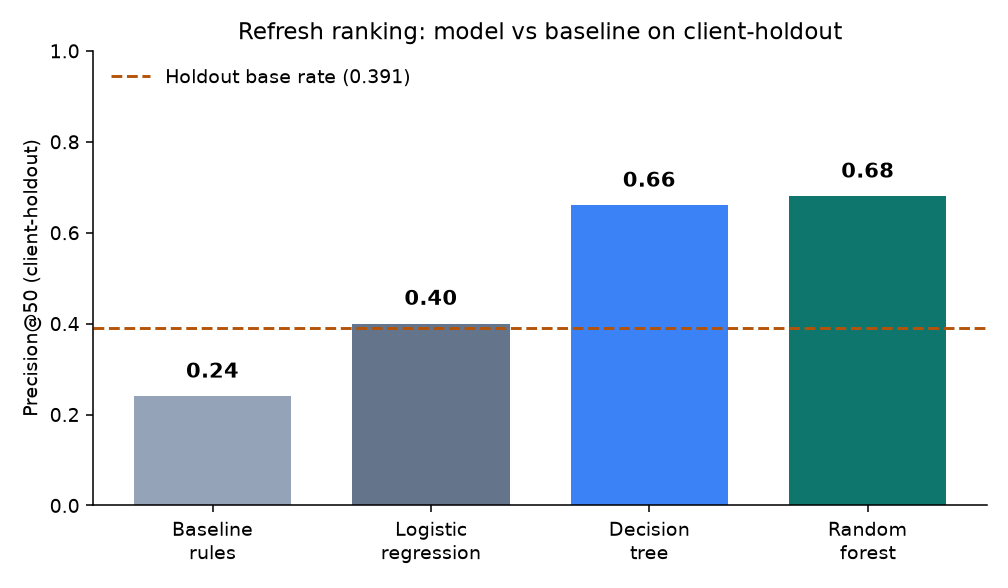

**split_audit_gap.png**

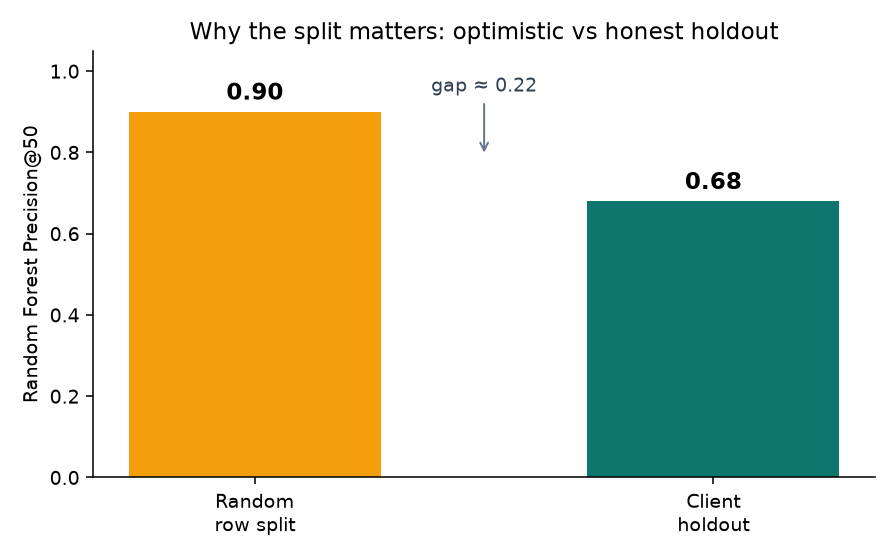

**top_features.png**

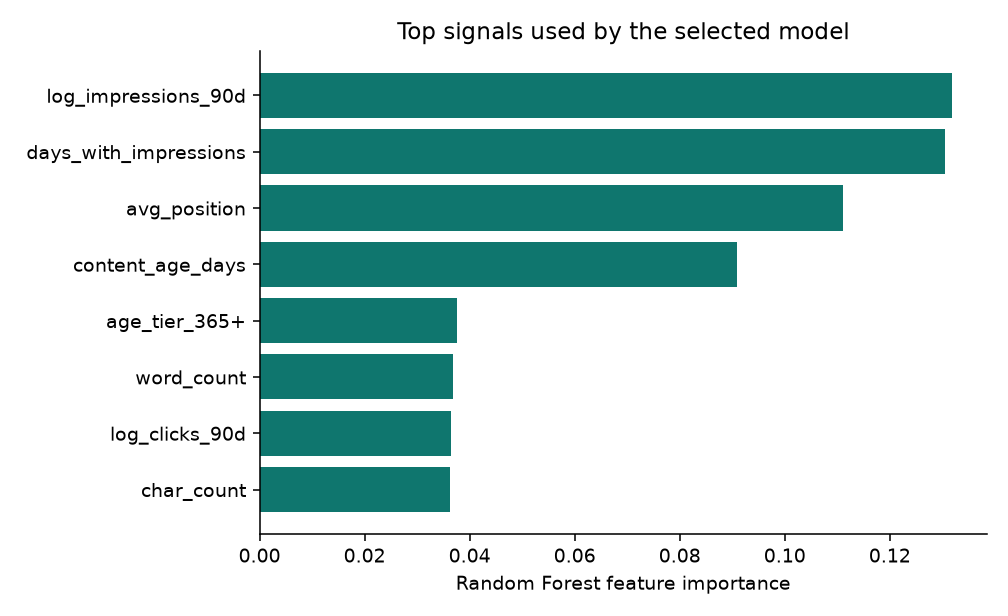

**action_mix.png**

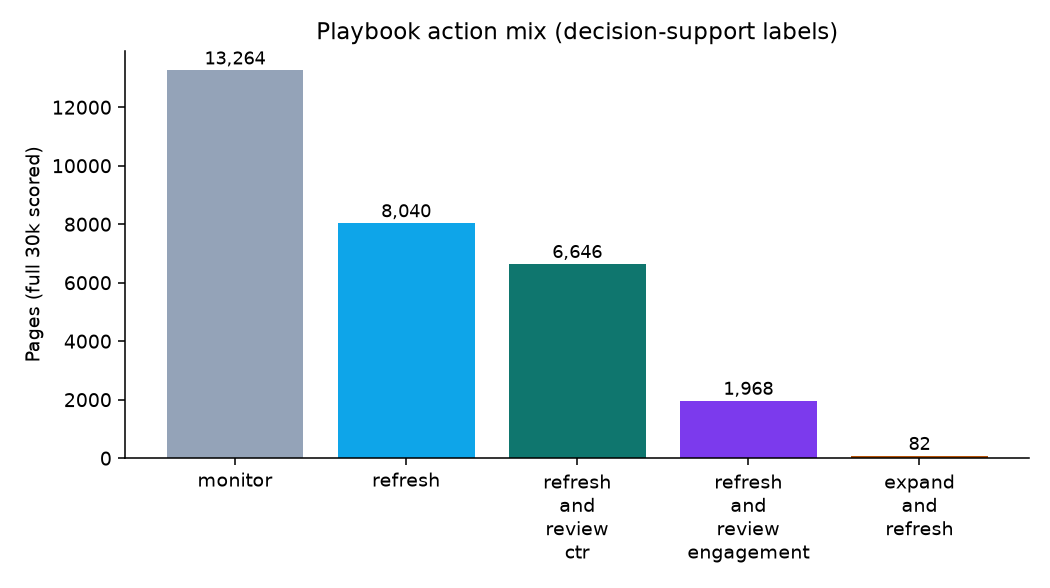

In [7]:
from IPython.display import Image, display, Markdown

paper_url = (ROOT / "submission" / "paper_url.txt").read_text().strip()
assert paper_url == "https://davionnic.github.io/flyrank-ml-internship/paper/"
print("paper_url.txt =", paper_url)

html = (ROOT / "docs" / "paper" / "index.html").read_text()
required = [
    "Abstract",
    "Introduction / Problem",
    "Data",
    "Methodology",
    "Results",
    "Limitations",
    "Ranked recommendations",
    "Reproducibility",
    "Acknowledgments",
    "https://flyrank.ai",
]
for needle in required:
    ok = needle in html
    print(f"[{'OK' if ok else 'MISSING'}] {needle}")
    assert ok, needle

chart_files = [
    "precision_at_50_holdout.png",
    "split_audit_gap.png",
    "top_features.png",
    "action_mix.png",
]
for name in chart_files:
    path = PAPER_CHARTS / name
    assert path.exists(), path
    display(Markdown(f"**{name}**"))
    display(Image(filename=str(path)))

## Self-check

Before calling the capstone done:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] Notebook intended to run top to bottom (loads committed JSON + optional CSV)
- [x] No client names, live URLs as identifiers, or private queries
- [x] Claims use careful words: observed, measured, directional, decision-support
- [x] Committed under `work/notebooks/capstone.ipynb` + `work/capstone_report.md`
- [x] Deployed paper has **all 9 sections** including Abstract + Acknowledgments (flyrank.ai)
- [x] **ML-12 closing cells below:** 5-minute demo outline + social-post cut + 3-sentence employer summary

Receipts verified in code: baseline Prec@50 **0.24**, RF Prec@50 **0.68**, holdout base rate **0.391**, train/test **27675 / 2325**, `random_state=42`, client-holdout.

## ML-12 — Tell the story (closing)

### Five-minute demo outline

| Min | Beat | What you say / show |
|---:|---|---|
| 0:00–0:40 | The decision | Content teams cannot re-audit 30k pages. Ranked triage: which URLs open first when demand looks soft? |
| 0:40–1:20 | The frame | Page-level ranking. Proxy: `is_declining_label = (trend_direction == "down")`. Queue with reason codes — not “SEO magic.” |
| 1:20–2:10 | Why the rule fails | Hand baseline on client-holdout: Prec@50 = **0.240**. Too many false opens. |
| 2:10–3:20 | What changed | RF, 52 features, no label leaks. 6 clients out, 27,675 / 2,325. Prec@50 = **0.680** (34/50). Lift ≈ **2.8×**; base rate 0.391. |
| 3:20–4:10 | Honest split + playbook | Random row would claim 0.90 — inflated. Client-holdout 0.680 ships. Blend ~0.7 model + ~0.3 baseline → actions + reasons. |
| 4:10–4:50 | Limits | Decision-support, not causal. Proxy ≠ editor judgment. Snapshot data. Does not predict Google’s algorithm. Open the paper URL. |
| 4:50–5:00 | Close | “Next stress-test: time-split holdout or editor accept/reject logging?” |

**Do not say:** “causes traffic,” “beats Google,” “proves refresh works.”

### Social-post cut

I spent this internship on one boring, useful question:

**Which existing pages should a reviewer open first when demand looks like it’s slipping?**

Data: FlyRank’s anonymized content-refresh set — 30,000 pages × 44 columns.

Method: client-holdout ranking (no client in both train and test). Transparent hand rules vs a Random Forest. Label is a decline **proxy**, not editor ground truth. Features exclude the label fields on purpose.

Result on that holdout:
- Baseline Prec@50 = **0.240**
- Random Forest Prec@50 = **0.680** (~2.8×)
- Holdout base rate = 0.391

That’s a decision-support queue with reason codes — not a causal SEO claim.

Paper: https://davionnic.github.io/flyrank-ml-internship/paper/  
Repo: https://github.com/Davionnic/flyrank-ml-internship

### Employer-facing summary (3 sentences)

I built a page-level **refresh / content opportunity** ranker that turns an anonymized 30,000-page FlyRank starter set into a review queue with reason codes and suggested actions. On a **client-holdout** split (train/test share no clients), a Random Forest reaches Precision@50 = **0.680** versus a transparent rule baseline at **0.240**, with the decline label treated as a proxy and leak fields kept out of the feature set. The system is **decision-support ranking** — it tells editors what to open first; it does not claim that refreshing a URL causes recovery.

In [8]:
# Final numeric lock — must match committed metrics the paper quotes
locks = {
    "baseline_prec50": (model["baseline_precision_at_50_holdout"], 0.24),
    "rf_prec50": (model["best_model_precision_at_50_holdout"], 0.68),
    "base_rate_test": (round(model["base_rate_test"], 5), 0.39097),
    "train_rows": (model["train_rows"], 27675),
    "test_rows": (model["test_rows"], 2325),
    "random_state": (model["random_state"], 42),
}
for name, (got, expect) in locks.items():
    print(f"{name}: got={got} expect≈{expect}")
    if isinstance(expect, float):
        assert abs(float(got) - expect) < 1e-4, (name, got, expect)
    else:
        assert got == expect, (name, got, expect)

print("\nCAPSTONE RECEIPTS LOCKED — notebook coherent with committed metrics.")

baseline_prec50: got=0.24 expect≈0.24
rf_prec50: got=0.68 expect≈0.68
base_rate_test: got=0.39097 expect≈0.39097
train_rows: got=27675 expect≈27675
test_rows: got=2325 expect≈2325
random_state: got=42 expect≈42

CAPSTONE RECEIPTS LOCKED — notebook coherent with committed metrics.
